# Henry Hub Strategy — Storage-Amplified D1--3 Version (Net Sharpe 2.228)

This notebook reproduces the selected research strategy in which South Central storage acts as an amplifier for the D1--3 fast-shock wind guard. On the NYMEX-session-, WNGSR-release-calendar-, and daily-available-BA Florida corrected 2019--2026 sample, the selected version records a net Sharpe of 2.228. It retains the 40% Central / 60% Florida EIA-930 sleeve and BSEE/Sabine pure short veto. Low storage amplifies a moderate fast bullish shock but cannot activate the guard by itself.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from naturalgas.evaluate_d1_3_storage_amplified_strategy import run

summary = run()
OUTPUT_DIR = ROOT / 'results/experiments/d1_3_storage_amplified'
print(f"Selected strategy rebuilt through {str(summary['sample_end'])[:10]} on {summary['trading_days']:,} trading days.")

Selected strategy rebuilt through 2026-07-13 on 1,748 trading days.


## Full-sample comparison

All rows use the same dates, futures returns, one-session lag, BSEE/Sabine veto, and 2.5 bp turnover cost.

In [2]:
metrics = pd.read_csv(OUTPUT_DIR / 'strategy_metrics.csv')
display(metrics[[
    'variant', 'trading_days', 'total_return', 'cagr', 'sharpe',
    'sortino', 'maximum_drawdown', 'mean_absolute_position'
]].style.format({
    'total_return': '{:.2%}', 'cagr': '{:.2%}', 'sharpe': '{:.3f}',
    'sortino': '{:.3f}', 'maximum_drawdown': '{:.2%}',
    'mean_absolute_position': '{:.2%}'
}))

,variant,trading_days,total_return,cagr,sharpe,sortino,maximum_drawdown,mean_absolute_position
0,d1_5_current,1748,240.11%,19.20%,2.119,3.663,-5.30%,10.69%
1,d1_3_no_guard,1748,231.09%,18.75%,2.181,3.787,-4.51%,10.43%
2,d1_3_storage_amplified,1748,237.16%,19.06%,2.228,3.880,-4.16%,10.20%


## Fixed evaluation blocks

The selected version improves the 2021--2023 validation block and the 2024+ first-look block, but annual results remain mixed.

In [3]:
periods = pd.read_csv(OUTPUT_DIR / 'period_metrics.csv')
period_table = periods.pivot(index='period', columns='variant', values='sharpe')
display(period_table.style.format('{:.3f}'))

variant,d1_3_no_guard,d1_3_storage_amplified,d1_5_current
period,,,
2025,0.154,0.234,-0.060
2026_ytd,2.099,1.981,2.225
development_2019_2020,2.757,2.781,2.785
first_look_2024_plus,1.779,1.835,1.718
validation_2021_2023,2.232,2.279,2.145


## Selected-strategy dashboard

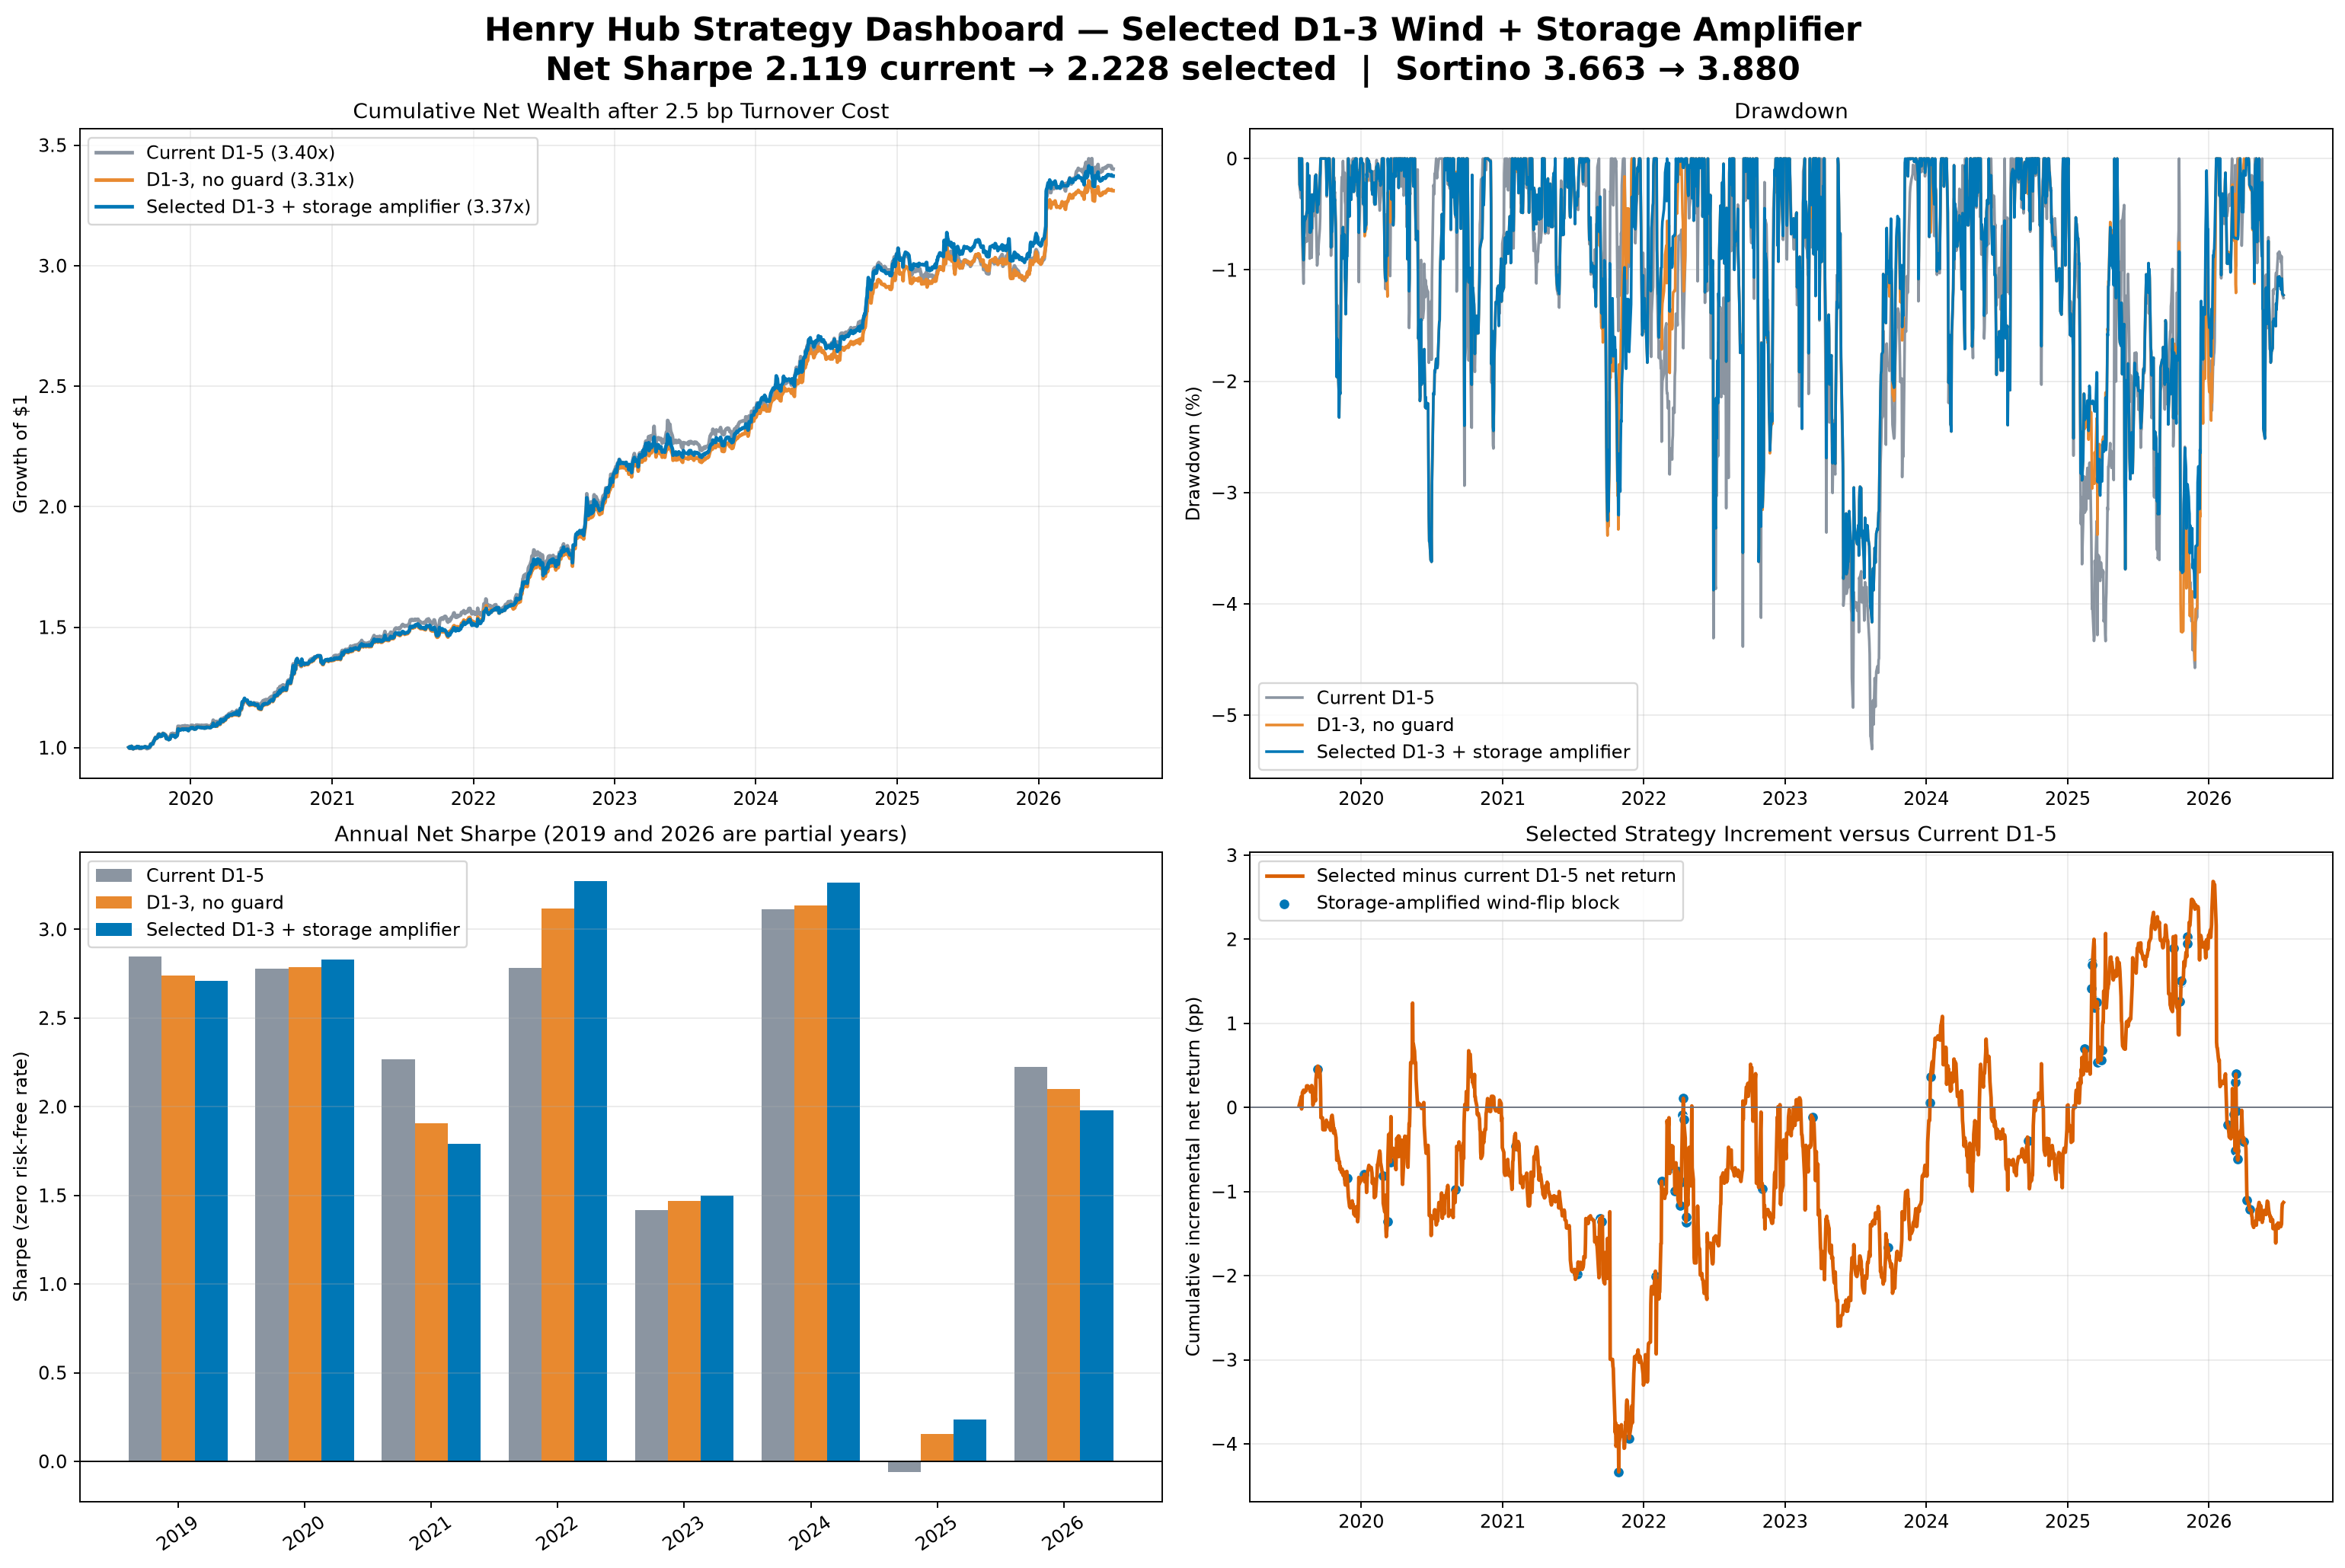

/home/syang_braeswoodcarbon_com/2026-intern-projects/henry-hub-natural-gas/results/experiments/d1_3_storage_amplified/latest_strategy_dashboard.png


In [4]:
dashboard_path = OUTPUT_DIR / 'latest_strategy_dashboard.png'
display(Image(filename=str(dashboard_path)))
print(dashboard_path)

## Interpretation

The calendar-corrected daily-available-BA Florida version raises common-sample net Sharpe from 2.119 to 2.228, raises Sortino from 3.663 to 3.880, and reduces maximum drawdown from -5.30% to -4.16%. It accepts a lower CAGR (19.06% versus 19.20%) and lower cumulative return than D1--5. The guard changes 60 held-return dates, helping 34 and hurting 26; it adds 1.79 percentage points versus unguarded D1--3 after costs. Partial-BA Florida observations remain in one continuous rolling history, and all five previously omitted returns are retained.